In [20]:
%matplotlib inline
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import distance
from scipy import stats
from warnings import simplefilter
simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

In [21]:
"""
You can start the code from here
"""
#Import the actual data
df_biofilm_filtered = pd.read_csv('Figurewise raw data/Biofilm_filtered.csv', index_col = 0)
df_biofilm_filtered.head()

,3,8,28,32,42,64,70,78,100,108,...,t_27_enrichment,t_39_enrichment,t_45_enrichment,t_63_enrichment,t_73_enrichment,t_81_enrichment,t_99_enrichment,t_107_enrichment,t_115_enrichment,t_137_enrichment
barcode,,,,,,,,,,,,,,,,,,,,,
GCGTATCGGAACTAGAAGGG,0,1,7,3,1,0,3,1,3,3,...,0.301030,0.602060,0.301030,0.602060,1.255273,1.146128,0.903090,0.000000,0.000000,0.000000
ACTGGAGAGACGCTCCAAGT,0,5,1,0,2,0,1,2,0,0,...,0.301030,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.301030,0.000000
GTTTTTAAATGTGTGCCCGG,1,4,1,3,9,0,4,0,0,0,...,-0.301030,-0.301030,0.397940,0.301030,-0.301030,-0.301030,-0.301030,-0.301030,-0.301030,-0.301030
GTACTAAATTGATGCCCATT,10,0,0,0,0,0,0,2,3,0,...,-0.740363,-1.041393,-1.041393,-0.740363,-1.041393,-1.041393,-1.041393,-1.041393,-1.041393,-1.041393
GGCCAAAGTACCTGTTAAAT,7,4,4,4,6,10,5,9,3,4,...,-0.903090,-0.425969,0.096910,-0.903090,-0.903090,-0.425969,-0.903090,-0.903090,-0.425969,-0.903090


In [22]:
df_biofilm_filtered.sort_values('168')[['t_168_f']]

,t_168_f
barcode,
AATGATGCTCAACCG-TAAA,0.000000
CGATTAGCTGAGGGCCGTTG,0.000000
TTAATATAGAGATGGCATAT,0.000000
--CGCTCGGCGCGAAACACG,0.000000
TCAAGATATT-TTTTCATAA,0.000000
...,...
GAATAGGGAATTATTGGTAG,0.006080
CGAACTCTCACAAGATTGCT,0.007708
ACTACATTATGCATCCGCCT,0.009076


In [23]:
#Extract the true barcodes from the neutral barcode list.
#for barcode in Neutral_barcodes.Barcode:
#    Neutral_barcodes_true.append(barcode[2:7]+barcode[9:14]+barcode[16:21]+barcode[23:28])

#We make a dataframe with just the Neutral barcodes.
df = df_biofilm_filtered[['3','8','28','32','42','64','70','78','100','108','116','134','140','144','160','164','168']]
df_neutral = df_biofilm_filtered.loc[(df>0).all(axis = 1) & ((df>10).any(axis = 1) == False)].sample(100)

#We create an artificial barcode called as 'WT', which is the sum of all neutral barcode.
#This wildtype barcode serves as a reference for all neutral barcodes.
df_biofilm_filtered.loc['WT'] = df_neutral.sum()

In [24]:
#Here I write the code for calculating the fitness for each variant
"""
OLS SM model : least squares model is better
"""
# import and fit an OLS model, check coefficients
import statsmodels.api as sm

def calc_slope_sklearn(row):
    """
    I use the sklearn regression package for weighted linear regression.
    We perform the linear regression over 3 consequitive time points.
    In the method, we return the slope.
    """
    y= row[[0,1,2]]
    #x = [0,1,2]
    x = [0,1,2]
    x = sm.add_constant(x)
    w = row[['0_w','1_w','2_w']]
    model = sm.WLS(y,x,weights=w)
    results = model.fit()
    return results.params.iloc[1]

def calc_slope_sklearn2(row):
    """
    I use the sklearn regression package for weighted linear regression.
    We perform the linear regression over 3 consequitive time points.
    In the method, we return the slope.

    For one of the timepoints, we have a timepoint missing. For the same
    we do regression over the missing timepoint taking the three consecutive
    timepoints one with a day difference and another with a 2 day difference.
    """
    y= row[[0,1,2]]
    x = [0,1,3]
    x = sm.add_constant(x)
    w = row[['0_w','1_w','2_w']]
    model = sm.WLS(y,x,weights=w)
    results = model.fit()
    return results.params.iloc[1]

# import and fit an OLS model, check coefficients
import statsmodels.api as sm
def calc_slope_sklearn3(row):
    """
    I use the sklearn regression package for weighted linear regression.
    We perform the linear regression over 3 consequitive time points.
    In the method, we return the slope.

    For one of the timepoints, we have a timepoint missing. For the same
    we do regression over the missing timepoint taking the three consecutive
    timepoints one with a two day difference and another with a day difference.
    """
    y= row[[0,1,2]]
    x = [0,2,3]
    x = sm.add_constant(x)
    w = row[['0_w','1_w','2_w']]
    model = sm.WLS(y,x,weights=w)
    results = model.fit()
    return results.params.iloc[1]



def calc_r2_sklearn(row):
    """
    I use the sklearn regression package for weighted linear regression.
    We perform the linear regression over 3 consequitive time points.
    In the method, we return the R2.
    """
    y= row[[0,1,2]]
    x = [0,1,2]
    #x = [0,8.23,16.46]
    x = sm.add_constant(x)
    w = row[['0_w','1_w','2_w']]
    model = sm.WLS(y,x,weights=w)
    results = model.fit()
    return results.rsquared

def calc_error_sklearn(row):
    """
    I use the sklearn regression package for weighted linear regression.
    We perform the linear regression over 3 consequitive time points.
    In the method, we return the error in the estimation of slope.
    """
    y= row[[0,1,2]]
    x = [0,1,2]
    #x = [0,8.23,16.46]
    x = sm.add_constant(x)
    w = row[['0_w','1_w','2_w']]
    model = sm.WLS(y,x,weights=w)
    results = model.fit()
    return results.bse.iloc[1]

def calc_error_sklearn2(row):
    """
    I use the sklearn regression package for weighted linear regression.
    We perform the linear regression over 3 consequitive time points.
    In the method, we return the slope.
    """
    y= row[[0,1,2]]
    x = [0,1,3]
    x = sm.add_constant(x)
    w = row[['0_w','1_w','2_w']]
    model = sm.WLS(y,x,weights=w)
    results = model.fit()
    return results.bse.iloc[1]

def calc_error_sklearn3(row):
    """
    I use the sklearn regression package for weighted linear regression.
    We perform the linear regression over 3 consequitive time points.
    In the method, we return the slope.
    """
    y= row[[0,1,2]]
    x = [0,2,3]
    x = sm.add_constant(x)
    w = row[['0_w','1_w','2_w']]
    model = sm.WLS(y,x,weights=w)
    results = model.fit()
    return results.bse.iloc[1]

In [25]:
import warnings

# Suppress ONLY runtime warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

list_columns = ['3','8','28','42','64','70','78','100','108','116','134']
#df_biofilm_filtered = df_biofilm_filtered[list_columns]

#Initiate two lists to save the names of the ratio columns and weight columns.
ratio_columns = []
weight_coumns = []

#Here we estimate the log ratio in frequencies and the associated weights for linear regression
for colum in list_columns:
    #Estimating the log ratio
    df_biofilm_filtered.loc[:,colum+'ratio'] = ((df_biofilm_filtered[colum]+0.5)/(df_biofilm_filtered.loc['WT', colum]+0.5)).apply(np.log)
    ratio_columns.append(colum+'ratio')

    #Estimating the weigt
    df_biofilm_filtered.loc[:,colum+'weight'] = 1/(1/(df_biofilm_filtered[colum]+0.5)+1/(df_biofilm_filtered.loc['WT',colum]+0.5))
    weight_coumns.append(colum+'weight')

#We will estimate the slope of each trajectory in a rolling window of every 3 consecutive time points.
#Initiate a list to save the name of the slope columns
slope_columns = []
for i in range(0,9):
    print(i)
    print(list_columns[i:i+3])
    #The slopes for variants with low counts can be erroneous and associated with errors
    #We only calculate slopes for variants which have atleast 25 reads for all 3 consecutive time points
    #25/250000 = 0.0001 ~usually the number of reads associated with erroneous reads.
    df_slope = df_biofilm_filtered.loc[(df_biofilm_filtered[list_columns[i:i+3]] >= 50).any(axis = 1)][ratio_columns[i:i+3] + (weight_coumns[i:i+3])]
    df_slope.columns = [0,1,2,'0_w','1_w','2_w']

    #We now update the slope for each window
    df_biofilm_filtered['slope_'+str(i)] = df_slope.apply(calc_slope_sklearn,axis=1)
    slope_columns.append('slope_'+str(i))
    df_biofilm_filtered.loc[df_biofilm_filtered['slope_'+str(i)] < 0, 'slope_'+str(i)] = 0
    
    #We store the r2 for each variant for each window
    df_biofilm_filtered['r2_'+str(i)] = df_slope.apply(calc_r2_sklearn,axis=1)

    #We store the error for each variant for each window
    df_biofilm_filtered['error_'+str(i)] = df_slope.apply(calc_error_sklearn,axis=1)

df_biofilm_filtered

0
['3', '8', '28']
1
['8', '28', '42']
2
['28', '42', '64']
3
['42', '64', '70']
4
['64', '70', '78']
5
['70', '78', '100']
6
['78', '100', '108']
7
['100', '108', '116']
8
['108', '116', '134']


,3,8,28,32,42,64,70,78,100,108,...,error_5,slope_6,r2_6,error_6,slope_7,r2_7,error_7,slope_8,r2_8,error_8
barcode,,,,,,,,,,,,,,,,,,,,,
GCGTATCGGAACTAGAAGGG,0.0,1.0,7.0,3.0,1.0,0.0,3.0,1.0,3.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACTGGAGAGACGCTCCAAGT,0.0,5.0,1.0,0.0,2.0,0.0,1.0,2.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GTTTTTAAATGTGTGCCCGG,1.0,4.0,1.0,3.0,9.0,0.0,4.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GTACTAAATTGATGCCCATT,10.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,3.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GGCCAAAGTACCTGTTAAAT,7.0,4.0,4.0,4.0,6.0,10.0,5.0,9.0,3.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CTTGACGGAGGGCTG-ATTC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CGCACAAGAGAACGCGAAAC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CAGTAATTTCGTTATATAAT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
df_slope = df_biofilm_filtered.loc[(df_biofilm_filtered[['8','28','42']] >= 50).any(axis = 1)]\
[['8ratio','28ratio','42ratio','8weight','28weight','42weight']]
df_slope.columns = [0,1,2,'0_w','1_w','2_w']
#We now update the slope for each window
df_biofilm_filtered['slope_1'] = df_slope.apply(calc_slope_sklearn2,axis=1)
df_biofilm_filtered['error_1'] = df_slope.apply(calc_error_sklearn2,axis=1)
df_biofilm_filtered.loc[df_biofilm_filtered['slope_1'] < 0, 'slope_1'] = 0

df_slope = df_biofilm_filtered.loc[(df_biofilm_filtered[['28','42','64']] >= 50).any(axis = 1)]\
[['28ratio','42ratio','64ratio','28weight','42weight','64weight']]
df_slope.columns = [0,1,2,'0_w','1_w','2_w']
#We now update the slope for each window
df_biofilm_filtered['slope_2'] = df_slope.apply(calc_slope_sklearn3,axis=1)
df_biofilm_filtered['error_2'] = df_slope.apply(calc_error_sklearn3,axis=1)
df_biofilm_filtered.loc[df_biofilm_filtered['slope_2'] < 0, 'slope_2'] = 0


0.9621695937827446


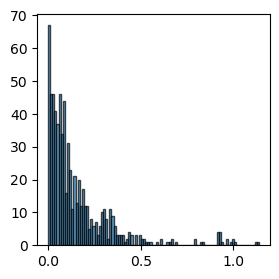

In [27]:
#Estimate the error cutoff over which, we eliminate all the slopes.
error_array = []
for i in range(9):
    error_array.append('error_'+str(i))
    
#We get a table with error for all calculated slopes for all variants.
df = pd.DataFrame(df_biofilm_filtered[error_array].stack())

#We make a histogram of error values. We set the cutoff for the error as 75th percentile.
plt.figure(figsize = [3,3])
plt.hist(df.loc[(df[0]>0)], bins=100, alpha=0.7, edgecolor="black")
cutoff = np.quantile(df.loc[(df[0]>0)], 0.99)
print(cutoff)

In [28]:
#Now we filter values over the cutodd value.

df_biofilm_filtered = df_biofilm_filtered.replace(np.nan,0)

for i in range(0,9):
    df_biofilm_filtered.loc[df_biofilm_filtered['error_'+str(i)] >= cutoff, 'slope_'+str(i)] = 0
    df_biofilm_filtered.loc[df_biofilm_filtered['error_'+str(i)] >= cutoff, 'error_'+str(i)] = 0

In [29]:
#We take the fitness with the maximum slope, assuming maximum fitness fitness
df_biofilm_filtered['Fitness'] = df_biofilm_filtered[slope_columns].max(axis = 1)
df_beneficial = df_biofilm_filtered.loc[df_biofilm_filtered.Fitness > 0]
df_beneficial

,3,8,28,32,42,64,70,78,100,108,...,slope_6,r2_6,error_6,slope_7,r2_7,error_7,slope_8,r2_8,error_8,Fitness
barcode,,,,,,,,,,,,,,,,,,,,,
TAAAGCGGAATGCTCCGAGG,3.0,9.0,9.0,18.0,17.0,14.0,23.0,50.0,43.0,48.0,...,0.000000,0.003290,0.090462,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.655513
CCATCCGTCTTTTTAGTATA,298.0,307.0,270.0,324.0,304.0,279.0,324.0,342.0,312.0,287.0,...,0.000000,0.915043,0.022018,0.120061,0.645268,0.089019,0.217197,0.974326,0.035257,0.217197
TCTTGCCTAAATATAATATG,0.0,0.0,1.0,10.0,41.0,21.0,52.0,21.0,6.0,6.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.162088
TGTTTCAGGTTAAAGAGACG,1.0,0.0,1.0,0.0,13.0,18.0,33.0,50.0,19.0,23.0,...,0.000000,0.672117,0.290190,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.493432
GGCATAACTATGCTGTAACT,10.0,10.0,2.0,4.0,24.0,18.0,46.0,64.0,48.0,37.0,...,0.000000,0.988834,0.027528,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.561944
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGGGGTCGTTCGTCTTGTAC,170.0,192.0,193.0,188.0,178.0,191.0,280.0,445.0,483.0,633.0,...,0.195009,0.875958,0.073383,0.460778,0.970464,0.080386,0.577719,0.999681,0.010313,0.577719
TTGAACTAATAAGCATGGGT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.891197,0.908489,0.917603,2.891197
GGTAATGGTAGATATATTCA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,77.0,119.0,...,0.572527,0.568506,0.498788,0.508994,0.999244,0.014004,0.279239,0.780429,0.148114,0.572527


0.9208545615619519
                            WLS Regression Results                            
Dep. Variable:                     mu   R-squared:                       0.921
Model:                            WLS   Adj. R-squared:                  0.917
Method:                 Least Squares   F-statistic:                     244.3
Date:                Thu, 13 Aug 2026   Prob (F-statistic):           4.85e-13
Time:                        19:06:56   Log-Likelihood:                -30.757
No. Observations:                  23   AIC:                             65.51
Df Residuals:                      21   BIC:                             67.78
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.5828      0.377 

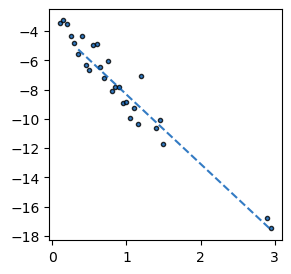

In [30]:
plt.figure(figsize = [3,3])
df_DFE = pd.DataFrame(((df_beneficial["Fitness"] / 0.05).round() * 0.05).value_counts()).reset_index()\
.sort_values('Fitness').rename(columns = {'count':'Count'})

mu = {}
for s in df_DFE.Fitness:
    mu[round(s,3)] = df_biofilm_filtered.loc[((df_biofilm_filtered["Fitness"] / 0.05).round() * 0.05) == s].t_117_f.sum()*s/(np.exp(s*10))
df_DFE = pd.DataFrame(mu, index=[0]).transpose()
df_DFE = df_DFE.rename(columns={0:'mu'})

plt.plot(df_DFE.index, df_DFE.mu.apply(np.log10), 'o', markersize = 3,\
         markeredgecolor = 'black', color = '#005AB5', alpha = 0.8, label = 'Rep A')

df_DFE = df_DFE.loc[df_DFE.mu > 0]

df_plot = df_DFE.loc[df_DFE.index > 0.3]
y= df_plot.mu.apply(np.log10)
x = df_plot.index
X = sm.add_constant(x)

model = sm.WLS(y,X)
results = model.fit()

print(results.rsquared)
print(results.summary())

y_pred = results.predict(X)

plt.plot(x, y_pred, '--', markersize = 5,\
         markeredgecolor = 'black', color = '#005AB5', alpha = 0.8,)
print(df_DFE.mu.sum())

df_DFE.to_csv('DFE2.csv')

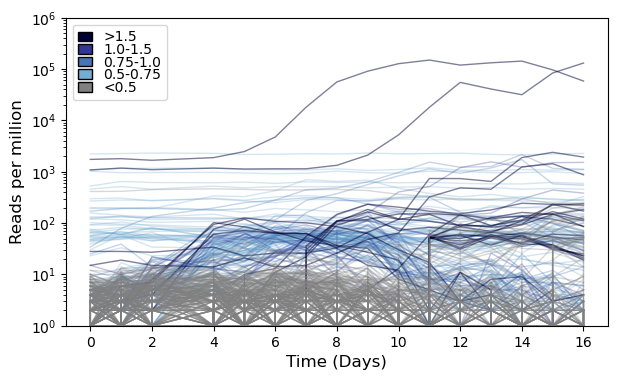

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Original columns (string sample names)
list_columns = ['3','8','28','32','42','64','70','78','100','108','116','134','140','144','160','164','168']

clean_columns = ['3','8','28','42','64','70','78','100','108','116','134','140','144','160','164','168']

# Remove problematic column '33'

# Define actual timepoints for remaining samples
timepoints = np.array([0,1,2,4,5,6,7,8,9,10,11,12,13,14,15,16])


fig, ax = plt.subplots(figsize=(7,4))

from scipy.ndimage import gaussian_filter1d

# Extract data for clean columns
df_plot = df_beneficial.loc[df_beneficial.Fitness.round(2) <= 0.5]
df_clean = df_plot[(df_plot[list_columns] >= 0).any(axis = 1)][clean_columns]
# Plot each lineage trajectory explicitly with correct x values
for _, row in df_clean.iterrows():
    ax.plot(timepoints, row.values, alpha=0.3, linewidth=1, color='#74add1')


# Extract data for clean columns
df_plot = df_beneficial.loc[df_beneficial.Fitness.round(2).between(0.5,0.75)]
df_clean = df_plot[(df_plot[list_columns] >= 0).any(axis = 1)][clean_columns]
# Plot each lineage trajectory explicitly with correct x values
for _, row in df_clean.iterrows():
    ax.plot(timepoints, row.values, alpha=0.3, linewidth=1, color='#4575b4')

# Extract data for clean columns
df_plot = df_beneficial.loc[df_beneficial.Fitness.round(2).between(0.75,1)]
df_clean = df_plot[(df_plot[list_columns] >= 0).any(axis = 1)][clean_columns]
# Plot each lineage trajectory explicitly with correct x values
for _, row in df_clean.iterrows():
    ax.plot(timepoints, row.values, alpha=0.3, linewidth=1, color='#313695')


# Extract data for clean columns
df_plot = df_beneficial.loc[df_beneficial.Fitness.round(2) >= 1]
df_clean = df_plot[(df_plot[list_columns] >= 0).any(axis = 1)][clean_columns]
# Plot each lineage trajectory explicitly with correct x values
for _, row in df_clean.iterrows():
    ax.plot(timepoints, row.values, alpha=0.5, linewidth=1, color='#000033')

# Extract data for clean columns
df_plot = df_biofilm_filtered.loc[df_biofilm_filtered.Fitness.round(2) == 0.0]
df_plot = df_plot[(df_plot[list_columns] >= 50).any(axis = 1)][list_columns]
df_clean = df_plot[clean_columns]
# Plot each lineage trajectory explicitly with correct x values
for _, row in df_clean.iterrows():
    ax.plot(timepoints, row.values, alpha=0.3, linewidth=1, color='grey')

# Format axes
ax.set_yscale('log')
ax.set_xlabel('Time (Days)', fontsize=12)
ax.set_ylabel('Reads per million', fontsize=12)
#df_biofilm_filtered.loc[df_biofilm_filtered.Fitness.round(2).between(0.05,0.075)].sort_values('Fitness')

# Format axes
ax.set_yscale('log')
ax.set_xlabel('Time (Days)', fontsize=12)
ax.set_ylabel('Reads per million', fontsize=12)
#df_biofilm_filtered.loc[df_biofilm_filtered.Fitness.round(2).between(0.05,0.075)].sort_values('Fitness')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#000033', edgecolor='black',label='>=1.0'),\
                  Patch(facecolor='#313695', edgecolor='black',label='0.75-1'),\
                  Patch(facecolor='#4575b4', edgecolor='black',label='0.5-0.75'),\
                   Patch(facecolor='#74add1', edgecolor='black',label='<0.5'),\
                  Patch(facecolor='grey', edgecolor='black',label='Neutral')]

ax.legend(legend_elements, ['>1.5','1.0-1.5','0.75-1.0','0.5-0.75','<0.5','0'],labelspacing=-0.1, handlelength=1, loc='upper left')
plt.ylim([1,10**6])
plt.savefig('Figures paper/Lineage trajectories by Fitness 2.svg', format = 'svg', dpi = 300)

['3', '8', '28', '32', '42', '64', '70', '78', '100', '108', '116', '134', '140', '144', '160', '164', '168']
KstestResult(statistic=np.float64(0.38498448627024484), pvalue=np.float64(1.2021735952754879e-18), statistic_location=np.float64(0.0), statistic_sign=np.int8(1))


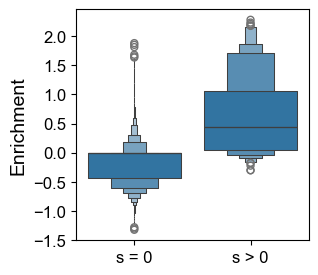

In [32]:
print(list_columns)
df_biofilm_filtered.loc[:, 'Is_fit'] = 'No'
df_biofilm_filtered.loc[df_biofilm_filtered.Fitness > 0, 'Is_fit'] = 'Yes'
plt.figure(figsize = [3,3])

sns.boxenplot(data = df_biofilm_filtered.loc[df_biofilm_filtered.index != 'WT'], x = 'Is_fit', y = 't_134_enrichment')
#sns.stripplot(data = df_biofilm_filtered, x = 'Is_fit', y = 't_169_enrichment')

plt.yticks(fontname = 'Arial',fontsize = 12)
plt.xticks([0,1], ['s = 0', 's > 0'], fontname = 'Arial',fontsize = 12);
plt.ylabel('Enrichment', fontname = 'Arial',fontsize = 14)
plt.xlabel('', fontname = 'Arial',fontsize = 14)

plt.savefig('Figures paper/Fitness and enrichment Final B.svg', format = 'svg', dpi = 300)


print(stats.ks_2samp(df_biofilm_filtered.loc[df_biofilm_filtered.Is_fit == 'No'].t_169_enrichment.dropna(),\
            df_biofilm_filtered.loc[df_biofilm_filtered.Is_fit == 'Yes'].t_169_enrichment.dropna()))

In [33]:
df_biofilm_filtered.loc[(df_biofilm_filtered.Fitness > 0)]\
[['3','8','28','32','42','64','70','78','100','108','116','134','140','144','160','164','168','Fitness']]\
.to_excel('Figurewise raw data/Supp fig 10 Replicate B Beneficial Mutations.xlsx')

In [34]:
df_biofilm_filtered.loc[(df_biofilm_filtered.Fitness > 0)]\
[['3','8','28','32','42','64','70','78','100','108','116','134','140','144','160','164','168','t_168_f','Fitness']].sort_values('168')

,3,8,28,32,42,64,70,78,100,108,116,134,140,144,160,164,168,t_168_f,Fitness
barcode,,,,,,,,,,,,,,,,,,,
ATAGTCAGCGTTTGTCTATT,2.0,4.0,8.0,4.0,24.0,14.0,24.0,50.0,41.0,58.0,32.0,15.0,5.0,9.0,5.0,2.0,0.0,0.000000,0.648370
ACTTATAGCGGTAGAGGAGG,3.0,2.0,3.0,18.0,19.0,27.0,49.0,37.0,60.0,54.0,27.0,15.0,7.0,12.0,3.0,2.0,0.0,0.000000,0.185882
GTGTAGACAAGTTGTCAAAA,1.0,3.0,8.0,29.0,59.0,53.0,49.0,33.0,9.0,6.0,10.0,0.0,0.0,0.0,0.0,4.0,0.0,0.000000,0.930216
CTAAGGGCACAGAATTGGAA,0.0,0.0,1.0,8.0,21.0,45.0,29.0,88.0,42.0,52.0,18.0,1.0,13.0,6.0,4.0,9.0,0.0,0.000000,0.386074
AAACGTCGTCTCCCGTCTTT,4.0,2.0,5.0,8.0,6.0,12.0,6.0,46.0,26.0,52.0,9.0,9.0,2.0,2.0,2.0,2.0,0.0,0.000000,0.084326
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GAATAGGGAATTATTGGTAG,15.0,10.0,13.0,25.0,19.0,19.0,22.0,43.0,99.0,155.0,403.0,512.0,1198.0,1559.0,1229.0,1503.0,1520.0,0.006080,0.851452
CGAACTCTCACAAGATTGCT,28.0,28.0,27.0,33.0,34.0,23.0,26.0,26.0,33.0,66.0,118.0,738.0,735.0,647.0,1885.0,2389.0,1927.0,0.007708,1.454284
ACTACATTATGCATCCGCCT,2212.0,2262.0,2310.0,2388.0,2279.0,2167.0,2190.0,2239.0,2216.0,2307.0,2236.0,2253.0,2293.0,2173.0,2133.0,2218.0,2269.0,0.009076,0.123924


In [36]:
#Fraction of population
print("Fraction of population fit in planktonic: " + str(df_biofilm_filtered.loc[df_biofilm_filtered.Fitness > 0].t_168_f.sum()))
print("Fraction of population fit in planktonic: " + str(df_biofilm_filtered.loc[df_biofilm_filtered.Fitness > 0].t_172_f.sum()))
print("Fraction of population fit in planktonic: " + str(df_biofilm_filtered.loc[df_biofilm_filtered.Fitness > 0].t_173_f.sum()))
print("Fraction of population fit in planktonic: " + str(df_biofilm_filtered.loc[df_biofilm_filtered.Fitness > 0].t_174_f.sum()))


Fraction of population fit in planktonic: 0.8250120000000002
Fraction of population fit in planktonic: 0.268152
Fraction of population fit in planktonic: 0.328012
Fraction of population fit in planktonic: 0.350848


In [37]:
np.mean([0.268152,0.328012,0.350848])

np.float64(0.31567066666666665)

In [14]:
df_biofilm_filtered.to_csv('Figurewise raw data/Raw data with fitness Rep B.xlsx')

In [38]:
list_files = ['3','8','28','32','42','64','70','78','100','108','116','134','140','144','160','164','168',\
            '12','48','84','120','148','172','13','49','85','121','149','173','14','50','86','122','150','174',\
            '9','29','33','46','65','74','82','101','109','117','138','142','146','161','165','169',\
            '15','51','87','123','151','175','16','52','88','124','152','176','17','53','89','125','153','177',\
             '10','30','34','43','66','71','79','102','110','118','139','141','145','162','166','170',\
              '18','54','90','126','154','178','19','55','91','127','155','179','20','56','92','128','156','180',\
            '11','31','35','47','67','75','83','103','111','119','135','143','147','163','167','171',\
              '21','57','93','129','157','181','22','58','94','130','158','182','23','59','95','131','159','183',\
            '4','24','36','40','60','68','76','96','104','112','132','5','25','37','44','61','72','80','97','105','113','136',\
            '6','26','38','41','62','69','77','98','106','114','133','7','27','39','45','63','73','81','99','107','115','137']

for i in list_files:
    df_biofilm_filtered.loc[:,'t_'+i+'_f2'] = (df_biofilm_filtered[i]+1)/df_biofilm_filtered[i].sum()

In [40]:
import numpy as np
import pandas as pd
from itertools import combinations, product

# --- ENRICHMENT THRESHOLD ---
cols = [f"t_{i}_enrichment" for i in range(8, 12)]
enrichment_values = [
    df_biofilm_filtered[col].mean() + 1.96 * df_biofilm_filtered[col].std()
    for col in cols
]
enrichment_threshold = np.mean(enrichment_values) + 1.96 * np.std(enrichment_values)

enrichment_threshold

np.float64(0.6363152281681426)

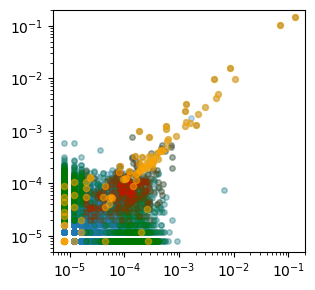

In [48]:
A1 = ['172']
A2 = ['173']
i = 0

df_plot = df_biofilm_filtered
plt.figure(figsize=[3.25,3])
plt.scatter(df_plot['t_'+A1[i]+'_f2'],df_plot['t_'+A2[i]+'_f2'], s = 15, alpha = 0.3, rasterized = True)

#plot the correlation between the frequencies for all barcodes enrihed in discA
df1 = df_plot.loc[(df_plot['t_'+A1[i]+'_enrichment'] >= enrichment_threshold)]
plt.scatter(df1['t_'+A1[i]+'_f2'], df1['t_'+A2[i]+'_f2'], s = 15, alpha = 0.1, color = 'green', rasterized = True)

#plot the correlation between the frequencies for all barcodes enrihed in discB
df2 = df_plot.loc[(df_plot['t_'+A2[i]+'_enrichment'] >= enrichment_threshold)]
plt.scatter(df2['t_'+A1[i]+'_f2'], df2['t_'+A2[i]+'_f2'], s = 15, alpha = 0.1, color = 'green', rasterized = True)

#plot the correlation between the frequencies for all barcodes enrihed in disc A amd disc B
df3 = df_plot.loc[(df_plot['t_'+A1[i]+'_enrichment'] >= enrichment_threshold) & (df_plot['t_'+A2[i]+'_enrichment'] >= enrichment_threshold)]
plt.scatter(df3['t_'+A1[i]+'_f2'], df3['t_'+A2[i]+'_f2'], s = 15, alpha = 0.1, color = 'red', rasterized = True)

df_plot = df_biofilm_filtered.loc[df_biofilm_filtered.Fitness > 0]
plt.scatter(df_plot.t_172_f2, df_plot.t_173_f2, alpha = 0.5, s = 20, rasterized = True, facecolors='orange')

plt.xlim(5*10**(-6), 0.2)
plt.ylim(5*10**(-6), 0.2)
    
plt.xscale('log')
plt.yscale('log')
plt.tight_layout()
plt.savefig('Figures paper/Sampled Mutations B1.svg', format = 'svg', dpi = 300)

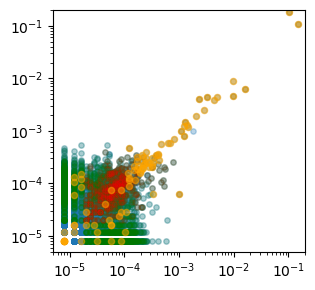

In [49]:
A1 = ['173']
A2 = ['174']
i = 0

df_plot = df_biofilm_filtered
plt.figure(figsize=[3.25,3])
plt.scatter(df_plot['t_'+A1[i]+'_f2'],df_plot['t_'+A2[i]+'_f2'], s = 15, alpha = 0.3, rasterized = True)

#plot the correlation between the frequencies for all barcodes enrihed in discA
df1 = df_plot.loc[(df_plot['t_'+A1[i]+'_enrichment'] >= enrichment_threshold)]
plt.scatter(df1['t_'+A1[i]+'_f2'], df1['t_'+A2[i]+'_f2'], s = 15, alpha = 0.1, color = 'green', rasterized = True)

#plot the correlation between the frequencies for all barcodes enrihed in discB
df2 = df_plot.loc[(df_plot['t_'+A2[i]+'_enrichment'] >= enrichment_threshold)]
plt.scatter(df2['t_'+A1[i]+'_f2'], df2['t_'+A2[i]+'_f2'], s = 15, alpha = 0.1, color = 'green', rasterized = True)

#plot the correlation between the frequencies for all barcodes enrihed in disc A amd disc B
df3 = df_plot.loc[(df_plot['t_'+A1[i]+'_enrichment'] >= enrichment_threshold) & (df_plot['t_'+A2[i]+'_enrichment'] >= enrichment_threshold)]
plt.scatter(df3['t_'+A1[i]+'_f2'], df3['t_'+A2[i]+'_f2'], s = 15, alpha = 0.1, color = 'red', rasterized = True)

df_plot = df_biofilm_filtered.loc[df_biofilm_filtered.Fitness > 0]
plt.scatter(df_plot.t_173_f2, df_plot.t_174_f2, alpha = 0.5, s = 20, rasterized = True, facecolors='orange')

plt.xlim(5*10**(-6), 0.2)
plt.ylim(5*10**(-6), 0.2)
    
plt.xscale('log')
plt.yscale('log')
plt.tight_layout()
plt.savefig('Figures paper/Sampled Mutations B2.svg', format = 'svg', dpi = 300)

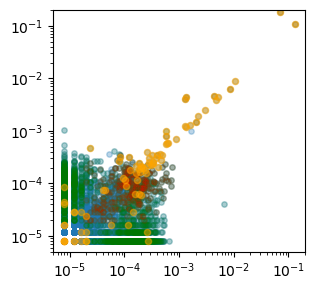

In [50]:
A1 = ['172']
A2 = ['174']
i = 0

df_plot = df_biofilm_filtered
plt.figure(figsize=[3.25,3])
plt.scatter(df_plot['t_'+A1[i]+'_f2'],df_plot['t_'+A2[i]+'_f2'], s = 15, alpha = 0.3, rasterized = True)

#plot the correlation between the frequencies for all barcodes enrihed in discA
df1 = df_plot.loc[(df_plot['t_'+A1[i]+'_enrichment'] >= enrichment_threshold)]
plt.scatter(df1['t_'+A1[i]+'_f2'], df1['t_'+A2[i]+'_f2'], s = 15, alpha = 0.1, color = 'green', rasterized = True)

#plot the correlation between the frequencies for all barcodes enrihed in discB
df2 = df_plot.loc[(df_plot['t_'+A2[i]+'_enrichment'] >= enrichment_threshold)]
plt.scatter(df2['t_'+A1[i]+'_f2'], df2['t_'+A2[i]+'_f2'], s = 15, alpha = 0.1, color = 'green', rasterized = True)

#plot the correlation between the frequencies for all barcodes enrihed in disc A amd disc B
df3 = df_plot.loc[(df_plot['t_'+A1[i]+'_enrichment'] >= enrichment_threshold) & (df_plot['t_'+A2[i]+'_enrichment'] >= enrichment_threshold)]
plt.scatter(df3['t_'+A1[i]+'_f2'], df3['t_'+A2[i]+'_f2'], s = 15, alpha = 0.1, color = 'red', rasterized = True)

df_plot = df_biofilm_filtered.loc[df_biofilm_filtered.Fitness > 0]
plt.scatter(df_plot.t_172_f2, df_plot.t_174_f2, alpha = 0.5, s = 20, rasterized = True, facecolors='orange')

plt.xlim(5*10**(-6), 0.2)
plt.ylim(5*10**(-6), 0.2)
    
plt.xscale('log')
plt.yscale('log')
plt.tight_layout()
plt.savefig('Figures paper/Sampled Mutations B3.svg', format = 'svg', dpi = 300)

In [52]:
#Define a new parameter to =see if variants are shared between discs
df_biofilm_filtered.loc[(df_biofilm_filtered.t_172_enrichment >= enrichment_threshold)\
& (df_biofilm_filtered.t_173_enrichment >= enrichment_threshold), 'Enrich'] = 'Both'

df_biofilm_filtered.loc[(df_biofilm_filtered.t_172_enrichment >= enrichment_threshold)\
& (df_biofilm_filtered.t_173_enrichment < enrichment_threshold), 'Enrich'] = 'One disc only'

df_biofilm_filtered.loc[(df_biofilm_filtered.t_172_enrichment < enrichment_threshold)\
& (df_biofilm_filtered.t_173_enrichment >= enrichment_threshold), 'Enrich'] = 'One disc only'

df_biofilm_filtered.loc[(df_biofilm_filtered.t_172_enrichment < enrichment_threshold)\
& (df_biofilm_filtered.t_173_enrichment < enrichment_threshold), 'Enrich'] = 'None'

In [53]:
print("Fraction of population on disc A with Fitness > 0")
print(df_biofilm_filtered.loc[(df_biofilm_filtered.Fitness > 0)].t_172_f.sum())

print("Fraction of population on disc A with Fitness > 0 and shared between multiple discs")
print(df_biofilm_filtered.loc[(df_biofilm_filtered.Enrich == 'Both') & (df_biofilm_filtered.Fitness > 0)].t_172_f.sum())

print("Fraction of population on disc B with Fitness > 0")
print(df_biofilm_filtered.loc[(df_biofilm_filtered.Fitness > 0)].t_173_f.sum())

print("Fraction of population on disc B with Fitness > 0 and shared between multiple discs")
print(df_biofilm_filtered.loc[(df_biofilm_filtered.Enrich == 'Both') & (df_biofilm_filtered.Fitness > 0)].t_173_f.sum())

print("Fraction of population on disc B with Fitness > 0")
print(df_biofilm_filtered.loc[(df_biofilm_filtered.Fitness > 0)].t_174_f.sum())

print("Fraction of population on disc B with Fitness > 0 and shared between multiple discs")
print(df_biofilm_filtered.loc[(df_biofilm_filtered.Enrich == 'Both') & (df_biofilm_filtered.Fitness > 0)].t_174_f.sum())

Fraction of population on disc A with Fitness > 0
0.268152
Fraction of population on disc A with Fitness > 0 and shared between multiple discs
0.226996
Fraction of population on disc B with Fitness > 0
0.328012
Fraction of population on disc B with Fitness > 0 and shared between multiple discs
0.28931199999999996
Fraction of population on disc B with Fitness > 0
0.350848
Fraction of population on disc B with Fitness > 0 and shared between multiple discs
0.31481599999999993
